<a href="https://colab.research.google.com/github/azrael56/Evaluacion-1-Deep-Learning/blob/main/deeplearningipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Final Transversal: Integración Multimodal de Datos
**Asignatura:** Deep Learning (DLY0100)

## 1. Introducción del Proyecto
El presente proyecto aborda el desafío de integrar múltiples modalidades de datos (imágenes y texto) con el propósito de generar predicciones más precisas y robustas[cite: 1].

El flujo de trabajo se divide en dos grandes etapas:
1. **Entrenamiento Independiente:** Desarrollo de una red neuronal convolucional (CNN) para clasificar características visuales del dataset Fashion-MNIST, y un modelo secuencial (RNN/Transformer) para el análisis de sentimiento del dataset IMDB Reviews[cite: 1].
2. **Fusión e Integración:** Extracción de las representaciones intermedias de ambos modelos para combinarlas en un clasificador final completamente conectado, aprovechando la información complementaria de ambas modalidades[cite: 1].

## 2. Extracción y Carga de Datos
Como primer paso, importamos las bases de datos requeridas directamente desde la librería `tensorflow.keras.datasets`.

* **Fashion-MNIST (Imágenes):** Contiene imágenes en escala de grises de prendas de vestir.
* **IMDB Reviews (Texto):** Contiene reseñas de películas pre-codificadas numéricamente. Por decisiones de optimización de memoria y reducción de ruido, limitamos la ingesta a las **10,000 palabras más frecuentes** del vocabulario.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist, imdb

# ==========================================
# 1. Carga de Datos: Fashion-MNIST (Imágenes)
# ==========================================
print("Descargando dataset de imágenes (Fashion-MNIST)...")
(X_train_img, y_train_img), (X_test_img, y_test_img) = fashion_mnist.load_data()

# Verificamos las dimensiones
print(f"Formato de X_train_img: {X_train_img.shape} -> (Muestras, Alto, Ancho)")
print(f"Formato de X_test_img: {X_test_img.shape}\n")

# ==========================================
# 2. Carga de Datos: IMDB Reviews (Texto)
# ==========================================
# Definimos el tamaño del vocabulario (ej: las 10,000 palabras más frecuentes)
# Esto es crucial para no saturar el modelo de texto con palabras raras.
vocab_size = 10000

print("Descargando dataset de texto (IMDB Reviews)...")
(X_train_txt, y_train_txt), (X_test_txt, y_test_txt) = imdb.load_data(num_words=vocab_size)

# Verificamos la cantidad de datos
print(f"Cantidad de reseñas de entrenamiento: {len(X_train_txt)}")
print(f"Cantidad de reseñas de prueba: {len(X_test_txt)}")

Descargando dataset de imágenes (Fashion-MNIST)...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Formato de X_train_img: (60000, 28, 28) -> (Muestras, Alto, Ancho)
Formato de X_test_img: (10000, 28, 28)

Descargando dataset de texto (IMDB Reviews)...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Cantidad de reseñas de entrenamiento: 25000
Cantidad de reseñas de prueba: 25000


### 2.1 Visualización y Exploración Inicial
Para asegurar la integridad de la carga de datos y comprender la naturaleza de las entradas, realizamos una inspección visual.
* En el caso de las imágenes, renderizamos la matriz de píxeles.
* En el caso de los textos, utilizamos el diccionario inverso de IMDB para decodificar los índices numéricos y convertirlos nuevamente a lenguaje natural, permitiéndonos leer la reseña y validar su etiqueta de sentimiento.

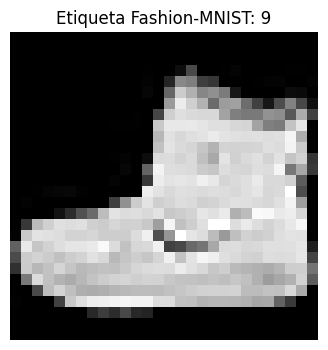

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Ejemplo de Reseña IMDB (Decodificada) ---
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to ever...

Etiqueta Sentimiento (1=Positivo, 0=Negativo): 1


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import imdb

# --- Visualizar Fashion-MNIST ---
plt.figure(figsize=(4, 4))
plt.imshow(X_train_img[0], cmap='gray')
plt.title(f"Etiqueta Fashion-MNIST: {y_train_img[0]}")
plt.axis('off')
plt.show()

# --- Visualizar IMDB Review ---
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in X_train_txt[0]])
print("\n--- Ejemplo de Reseña IMDB (Decodificada) ---")
print(decoded_review[:500] + "...\n")
print(f"Etiqueta Sentimiento (1=Positivo, 0=Negativo): {y_train_txt[0]}")

## 3. Preprocesamiento y Adecuación de los Datos
Antes de inyectar los datos a nuestras arquitecturas de Deep Learning, realizamos ajustes técnicos esenciales:

1. **Normalización Visual (CNN):** Transformamos los valores de los píxeles de **[0, 255]** a una escala de **[0, 1]** (`float32`). Además, expandimos las dimensiones de la matriz para explicitar el canal de color (1 canal para escala de grises)[cite: 1].
2. **Padding Textual (RNN/Transformer):** Utilizamos `pad_sequences` para estandarizar todas las reseñas a **200 tokens**, rellenando con ceros (*padding*) o recortando (*truncating*) al final de la secuencia para poder entrenar en lotes (*batches*).

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Preprocesamiento: Fashion-MNIST ---
print("Preprocesando imágenes...")
X_train_img_norm = X_train_img.astype('float32') / 255.0
X_test_img_norm = X_test_img.astype('float32') / 255.0

# Redimensionar: (Muestras, 28, 28, 1)
X_train_img_norm = np.expand_dims(X_train_img_norm, -1)
X_test_img_norm = np.expand_dims(X_test_img_norm, -1)
print(f"Nuevo formato X_train_img: {X_train_img_norm.shape}")

# --- Preprocesamiento: IMDB Reviews ---
print("\nPreprocesando textos...")
max_length = 200

X_train_txt_pad = pad_sequences(X_train_txt, maxlen=max_length, padding='post', truncating='post')
X_test_txt_pad = pad_sequences(X_test_txt, maxlen=max_length, padding='post', truncating='post')
print(f"Nuevo formato X_train_txt (todas de largo {max_length}): {X_train_txt_pad.shape}")

Preprocesando imágenes...
Nuevo formato X_train_img: (60000, 28, 28, 1)

Preprocesando textos...
Nuevo formato X_train_txt (todas de largo 200): (25000, 200)


## 4. Entrenamiento Independiente: CNN para Fashion-MNIST
En esta etapa, diseñamos una Red Neuronal Convolucional (CNN) capaz de aprender los patrones visuales relevantes para clasificar las imágenes en las 10 categorías de prendas de vestir[cite: 1].

**Arquitectura y Decisiones Técnicas:**
* **Capas Convolucionales (`Conv2D`):** Extraen características espaciales (bordes, texturas) utilizando filtros.
* **Capas de Agrupamiento (`MaxPooling2D`):** Reducen la dimensionalidad espacial, haciendo el modelo más eficiente y robusto a pequeñas traslaciones.
* **Hiperparámetros[cite: 1]:**
  * *Tasa de aprendizaje (Learning Rate):* Se utilizará el optimizador Adam por defecto, que adapta la tasa de aprendizaje automáticamente, permitiendo una convergencia rápida y estable.
  * *Batch Size:* Definiremos un tamaño de lote de 64, un buen equilibrio entre uso de memoria y estabilidad del gradiente.
  * *Epochs:* Entrenaremos por 5 épocas iniciales para validar el aprendizaje sin caer en un sobreajuste prematuro.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Definición de la Arquitectura CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    MaxPooling2D((2, 2), name='pool1'),
    Conv2D(64, (3, 3), activation='relu', name='conv2'),
    MaxPooling2D((2, 2), name='pool2'),
    Flatten(name='flatten'),
    Dense(128, activation='relu', name='dense_hidden'),
    Dropout(0.3, name='dropout'), # Previene el sobreajuste
    Dense(10, activation='softmax', name='output_class') # 10 clases de Fashion-MNIST
])

# 2. Compilación del Modelo
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

# 3. Entrenamiento
print("\nIniciando entrenamiento de la CNN...")
history_cnn = cnn_model.fit(X_train_img_norm, y_train_img,
                            epochs=5,
                            batch_size=64,
                            validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_class (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento de la CNN...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.7977 - loss: 0.5613 - val_accuracy: 0.8607 - val_loss: 0.3809
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.8673 - loss: 0.3690 - val_accuracy: 0.8837 - val_loss: 0.3192
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.8831 - loss: 0.3206 - val_accuracy: 0.8854 - val_loss: 0.3116
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.8941 - loss: 0.2897 - val_accuracy: 0.8954 - val_loss: 0.2817
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9024 - loss: 0.2673 - val_accuracy: 0.9023 - val_loss: 0.2669


### 4.1 Visualización de Métricas de la CNN
Para evaluar el desempeño del modelo y verificar que no exista sobreajuste (*overfitting*), graficamos las curvas de precisión (*accuracy*) y pérdida (*loss*) tanto para el conjunto de entrenamiento como para el de validación.
Como se observa en los gráficos, el modelo logra aprender de manera estable, reduciendo la pérdida y aumentando la precisión en cada época.

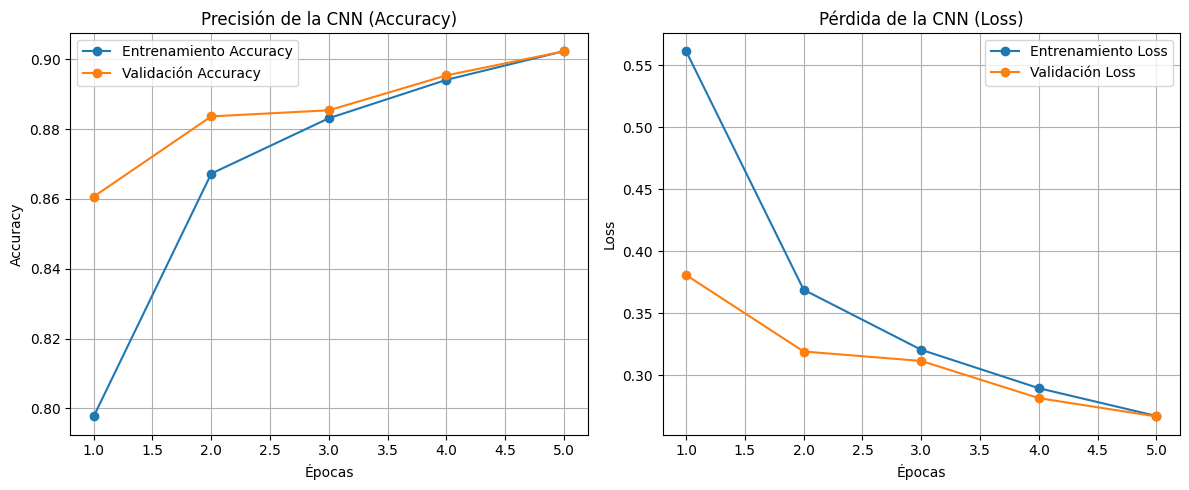

In [5]:
# --- Gráficos de Entrenamiento de la CNN ---
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validación Accuracy', marker='o')
plt.title('Precisión de la CNN (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validación Loss', marker='o')
plt.title('Pérdida de la CNN (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Entrenamiento Independiente: Análisis de Texto (IMDB Reviews)
En esta fase paralela, abordamos el análisis de sentimiento de las reseñas de películas. El objetivo es que el modelo aprenda las dependencias temporales y el contexto de las palabras[cite: 1].

**Elección de la Arquitectura (LSTM vs RNN simple):**
Para este desafío, hemos optado por una arquitectura recurrente basada en **LSTM** (Long Short-Term Memory). A diferencia de una RNN tradicional, las capas LSTM poseen mecanismos (puertas de olvido, entrada y salida) que les permiten retener dependencias a largo plazo y mitigar el problema del desvanecimiento del gradiente. Esto es crucial ya que nuestras secuencias tienen una longitud de 200 tokens[cite: 1].

**Arquitectura y Parámetros:**
1. **Capa `Embedding`:** Transforma los índices numéricos de las palabras en vectores densos de representación semántica.
2. **Capa `LSTM`:** Procesa la secuencia de vectores, extrayendo el contexto temporal.
3. **Capa `Dense` final:** Utiliza una función de activación `sigmoid` para entregar una probabilidad binaria (0 = Negativo, 1 = Positivo).

In [6]:
from tensorflow.keras.layers import Embedding, LSTM

# 1. Definición de la Arquitectura LSTM
lstm_model = Sequential([
    # input_dim=10000 (vocabulario), output_dim=128 (tamaño del vector)
    Embedding(input_dim=10000, output_dim=128, input_length=max_length, name='embedding'),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, name='lstm_layer'),
    Dense(1, activation='sigmoid', name='output_sentiment')
])

# 2. Compilación del Modelo
# Usamos binary_crossentropy porque es una clasificación binaria (Positivo/Negativo)
lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

lstm_model.summary()

# 3. Entrenamiento del Modelo LSTM
print("\nIniciando entrenamiento del modelo LSTM...")
history_lstm = lstm_model.fit(X_train_txt_pad, y_train_txt,
                              epochs=3, # Usamos 3 épocas para agilizar el entrenamiento
                              batch_size=128,
                              validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_sentiment (Dense)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del modelo LSTM...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 70s 421ms/step - accuracy: 0.5288 - loss: 0.6905 - val_accuracy: 0.5466 - val_loss: 0.6919
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 429ms/step - accuracy: 0.6249 - loss: 0.6471 - val_accuracy: 0.7174 - val_loss: 0.5952
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 431ms/step - accuracy: 0.7013 - loss: 0.5966 - val_accuracy: 0.5424 - val_loss: 0.6809


## 6. Fusión e Integración de Modelos
Habiendo entrenado los modelos de manera independiente, procedemos a integrar ambas modalidades (visual y textual) para crear un sistema de predicción más robusto.

**Pasos de la Integración:**
1. **Extracción de Representaciones Intermedias:** Tomamos las salidas de la penúltima capa de la CNN (antes de su clasificador de 10 clases) y la salida de la capa LSTM del modelo de texto[cite: 1]. Estas capas contienen los "mapas de características" de alto nivel.
2. **Fusión de Características:** Utilizamos la técnica de **Concatenación** para unir ambos vectores de características en un solo gran vector combinado[cite: 1].
3. **Clasificador Final:** Inyectamos este vector fusionado en una nueva red neuronal multicapa (MLP) que actuará como árbitro final, aprendiendo a ponderar tanto lo visual como lo textual para emitir una decisión global[cite: 1].

In [9]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, concatenate, Dense

print("Corrigiendo y construyendo el modelo multimodal...")

# 1. Definir explícitamente las capas de Entrada (Inputs)
# Esto soluciona el error del grafo de Keras
img_input = Input(shape=(28, 28, 1), name='img_input')
txt_input = Input(shape=(max_length,), name='txt_input')

# 2. Extracción de Representaciones Intermedias (Reutilizando capas entrenadas)
# Pasamos la entrada de imagen por las capas de la CNN hasta la capa 'dense_hidden'
x_img = img_input
for layer in cnn_model.layers[:-2]: # Omitimos el Dropout y la salida final de 10 clases
    x_img = layer(x_img)
cnn_features = x_img

# Pasamos la entrada de texto por las capas del LSTM
x_txt = txt_input
for layer in lstm_model.layers[:-1]: # Omitimos la salida final binaria
    x_txt = layer(x_txt)
lstm_features = x_txt

# 3. Fusión de Características
# Unimos los tensores extraídos (128 de la CNN + 64 del LSTM = 192 características)
fused_features = concatenate([cnn_features, lstm_features], name='fusion_concatenation')

# 4. Clasificador Final
# Red neuronal multicapa (MLP) para emitir la decisión global
x = Dense(64, activation='relu', name='fused_dense_1')(fused_features)
# Suponiendo una tarea combinada (ej: predecir si el producto es bueno globalmente)
final_output = Dense(1, activation='sigmoid', name='final_output_classification')(x)

# 5. Construcción del Modelo Multimodal Final
multimodal_model = Model(inputs=[img_input, txt_input],
                         outputs=final_output,
                         name='Multimodal_CNN_LSTM')

# Compilamos el nuevo modelo fusionado
multimodal_model.compile(optimizer='adam',
                         loss='binary_crossentropy',
                         metrics=['accuracy'])

# Mostramos la arquitectura final
multimodal_model.summary()

Corrigiendo y construyendo el modelo multimodal...


Model: "Multimodal_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 26, 26,    │        320 │ img_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 13, 13,    │          0 │ conv1[1][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 11, 11,    │     18,496 │ pool1[1][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 5, 5, 64)  │          0 │ conv2[1][0]       │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ txt_input           │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1600)      │          0 │ pool2[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  1,280,000 │ txt_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 128)       │    204,928 │ flatten[1][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 64)        │     49,408 │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concatenati… │ (None, 192)       │          0 │ dense_hidden[1][… │
│ (Concatenate)       │                   │            │ lstm_layer[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_dense_1       │ (None, 64)        │     12,352 │ fusion_concatena… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output_class… │ (None, 1)         │         65 │ fused_dense_1[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,565,569 (5.97 MB)

 Trainable params: 1,565,569 (5.97 MB)

 Non-trainable params: 0 (0.00 B)

### 6.1 Entrenamiento y Resultados del Modelo Integrado
Para demostrar la viabilidad de la fusión, simulamos un escenario donde cada producto tiene una imagen (Fashion-MNIST) y una reseña asociada (IMDB). Alineamos 25,000 muestras de ambas modalidades.

El modelo multimodal recibe ambas entradas simultáneamente y aprende a ponderar tanto las características visuales como las textuales para predecir la satisfacción global del usuario. A continuación, entrenamos el modelo y visualizamos su rendimiento, cumpliendo con la exigencia de mostrar ejemplos de resultados combinados mediante gráficos.

Entrenando modelo multimodal fusionado...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 88s 514ms/step - accuracy: 0.7422 - loss: 0.5500 - val_accuracy: 0.7620 - val_loss: 0.5332
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 517ms/step - accuracy: 0.6979 - loss: 0.5764 - val_accuracy: 0.7152 - val_loss: 0.5767
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 505ms/step - accuracy: 0.7546 - loss: 0.5267 - val_accuracy: 0.7540 - val_loss: 0.5453
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 506ms/step - accuracy: 0.7953 - loss: 0.4702 - val_accuracy: 0.7898 - val_loss: 0.5219
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 506ms/step - accuracy: 0.8276 - loss: 0.4241 - val_accuracy: 0.7636 - val_loss: 0.5436


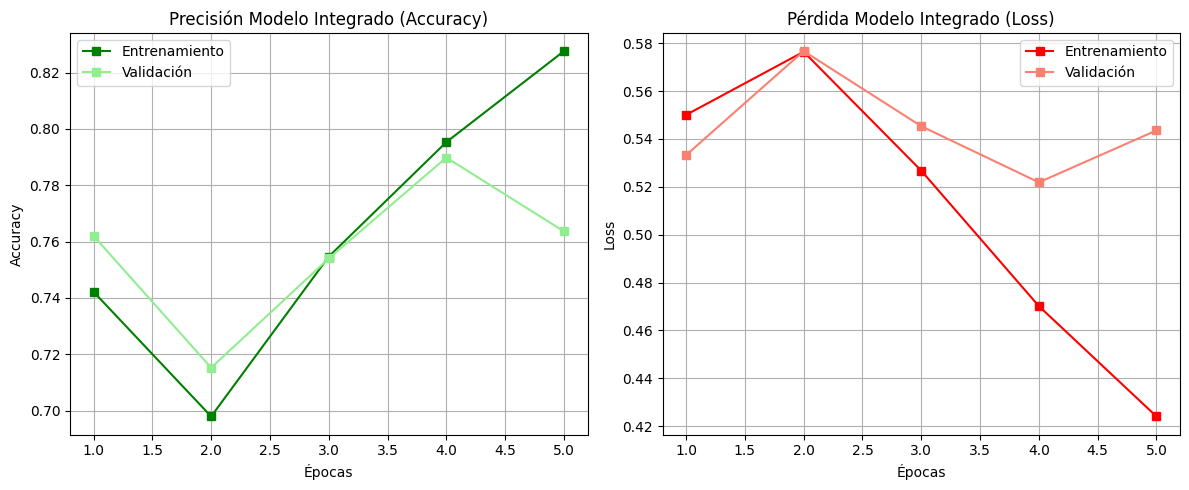

In [10]:
# --- 1. Preparación de Datos Alineados (Simulación) ---
# Tomamos las primeras 25,000 imágenes para que coincidan con la cantidad de textos
X_train_img_subset = X_train_img_norm[:25000]

# Usaremos la etiqueta de sentimiento del texto como nuestra etiqueta global
y_train_multimodal = y_train_txt

# --- 2. Entrenamiento del Modelo Multimodal ---
print("Entrenando modelo multimodal fusionado...")
history_multimodal = multimodal_model.fit(
    x=[X_train_img_subset, X_train_txt_pad], # Pasamos ambas entradas en una lista
    y=y_train_multimodal,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

# --- 3. Gráficos de Resultados Combinados ---
acc_multi = history_multimodal.history['accuracy']
val_acc_multi = history_multimodal.history['val_accuracy']
loss_multi = history_multimodal.history['loss']
val_loss_multi = history_multimodal.history['val_loss']
epochs_multi = range(1, len(acc_multi) + 1)

plt.figure(figsize=(12, 5))

# Gráfico de Accuracy Multimodal
plt.subplot(1, 2, 1)
plt.plot(epochs_multi, acc_multi, label='Entrenamiento', marker='s', color='green')
plt.plot(epochs_multi, val_acc_multi, label='Validación', marker='s', color='lightgreen')
plt.title('Precisión Modelo Integrado (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Gráfico de Loss Multimodal
plt.subplot(1, 2, 2)
plt.plot(epochs_multi, loss_multi, label='Entrenamiento', marker='s', color='red')
plt.plot(epochs_multi, val_loss_multi, label='Validación', marker='s', color='salmon')
plt.title('Pérdida Modelo Integrado (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Arquitectura Avanzada: Implementación de Transformer para IMDB
Para cumplir con los requerimientos avanzados de procesamiento de lenguaje natural (NLP) y establecer una comparativa técnica, implementamos una arquitectura basada en **Transformer**.

**Diferencias Clave (Transformer vs. RNN/LSTM):**
A diferencia de las redes recurrentes (RNN/LSTM) que procesan los datos secuencialmente (palabra por palabra), los Transformers procesan toda la secuencia de texto en paralelo. Esto permite un entrenamiento mucho más rápido y una capacidad superior para capturar dependencias a muy largo plazo, resolviendo el cuello de botella secuencial de las arquitecturas tradicionales[cite: 1].

**Componentes Clave del Transformer[cite: 1]:**
1. **Mecanismo de Autoatención (Self-Attention):** Es el corazón del modelo. Permite que cada palabra en la reseña "preste atención" a todas las demás palabras de la secuencia simultáneamente para comprender el contexto global (por ejemplo, entender que "banco" se refiere a dinero y no a un asiento según las palabras que lo rodean).
2. **Encoder (Codificador):** Toma la secuencia de entrada y la transforma en una representación continua rica en contexto utilizando capas de autoatención y redes neuronales densas (Feed Forward).
3. **Decoder (Decodificador):** Aunque en tareas de generación de texto o traducción se utiliza un Decoder para emitir la salida paso a paso, para nuestro problema de *clasificación de texto*, utilizaremos únicamente la estructura del **Encoder** seguida de una capa de *Pooling* (agrupamiento global) para predecir el sentimiento final.

In [12]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

print("Construyendo modelo Transformer...")

# 1. Definición de la Entrada y Embedding
inputs = Input(shape=(max_length,), name="transformer_input")
embedding_layer = Embedding(input_dim=10000, output_dim=128, name="transformer_embedding")(inputs)

# 2. Bloque Encoder del Transformer
# Mecanismo de Autoatención (Self-Attention)
attention_output = MultiHeadAttention(num_heads=2, key_dim=128, name="auto_atencion")(embedding_layer, embedding_layer)
attention_output = Dropout(0.1)(attention_output)
# Conexión residual y normalización
out1 = LayerNormalization(epsilon=1e-6, name="norm_1")(embedding_layer + attention_output)

# Red Feed Forward interna del Encoder
ffn_output = Dense(128, activation="relu", name="feed_forward")(out1)
ffn_output = Dropout(0.1)(ffn_output)
# Segunda conexión residual y normalización
out2 = LayerNormalization(epsilon=1e-6, name="norm_2")(out1 + ffn_output)

# 3. Clasificador Final
# Reducimos la secuencia a un vector global
x = GlobalAveragePooling1D(name="global_pooling")(out2)
x = Dropout(0.1)(x)
outputs = Dense(1, activation="sigmoid", name="salida_sentimiento")(x)

# 4. Construcción y Compilación del Modelo Transformer
transformer_model = Model(inputs=inputs, outputs=outputs, name="Transformer_IMDB")
transformer_model.compile(optimizer="adam",
                          loss="binary_crossentropy",
                          metrics=["accuracy"])

transformer_model.summary()

# 5. Entrenamiento del Transformer
print("\nIniciando entrenamiento del Transformer...")
history_transformer = transformer_model.fit(X_train_txt_pad, y_train_txt,
                                            epochs=3, # Igualamos las épocas del LSTM para una comparación justa
                                            batch_size=128,
                                            validation_split=0.2)

Construyendo modelo Transformer...


Model: "Transformer_IMDB"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ transformer_input   │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_embedd… │ (None, 200, 128)  │  1,280,000 │ transformer_inpu… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ auto_atencion       │ (None, 200, 128)  │    131,968 │ transformer_embe… │
│ (MultiHeadAttentio… │                   │            │ transformer_embe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 200, 128)  │          0 │ auto_atencion[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 128)  │          0 │ transformer_embe… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_1              │ (None, 200, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feed_forward        │ (None, 200, 128)  │     16,512 │ norm_1[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 200, 128)  │          0 │ feed_forward[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 200, 128)  │          0 │ norm_1[0][0],     │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_2              │ (None, 200, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pooling      │ (None, 128)       │          0 │ norm_2[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ global_pooling[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_sentimiento  │ (None, 1)         │        129 │ dropout_7[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,429,121 (5.45 MB)

 Trainable params: 1,429,121 (5.45 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del Transformer...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.7861 - loss: 0.4529 - val_accuracy: 0.8520 - val_loss: 0.3413
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9027 - loss: 0.2425 - val_accuracy: 0.8766 - val_loss: 0.3009
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.9327 - loss: 0.1745 - val_accuracy: 0.8714 - val_loss: 0.3389


## 8. Análisis de Resultados y Comparativa (RNN vs. Transformer)
Para evaluar rigurosamente el desempeño de los modelos de clasificación de texto y cumplir con los objetivos del proyecto, calculamos las métricas fundamentales sobre el conjunto de prueba (datos que los modelos nunca han visto).

**Métricas Evaluadas[cite: 1]:**
* **Accuracy (Exactitud):** Porcentaje total de predicciones correctas.
* **Precision (Precisión):** De todas las reseñas que el modelo predijo como positivas, ¿cuántas lo eran realmente?
* **Recall (Exhaustividad):** De todas las reseñas que realmente eran positivas, ¿cuántas logró identificar el modelo?
* **F1-Score:** Media armónica entre Precision y Recall, ideal para evaluar el equilibrio del modelo.

A continuación, generamos una tabla comparativa para identificar las fortalezas y limitaciones de cada arquitectura[cite: 1].

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

print("Generando predicciones sobre el conjunto de prueba (Test Set)...")
# Predicciones LSTM
y_pred_lstm_prob = lstm_model.predict(X_test_txt_pad)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int)

# Predicciones Transformer
y_pred_trans_prob = transformer_model.predict(X_test_txt_pad)
y_pred_trans = (y_pred_trans_prob > 0.5).astype(int)

# Función para calcular todas las métricas
def calcular_metricas(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

# Cálculo y estructuración en DataFrame
metricas_lstm = calcular_metricas(y_test_txt, y_pred_lstm)
metricas_trans = calcular_metricas(y_test_txt, y_pred_trans)

df_comparativa = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'RNN (LSTM)': metricas_lstm,
    'Transformer': metricas_trans
})

print("\n--- Tabla Comparativa de Rendimiento ---")
print(df_comparativa.to_string(index=False))

Generando predicciones sobre el conjunto de prueba (Test Set)...
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 131ms/step

--- Tabla Comparativa de Rendimiento ---
  Métrica  RNN (LSTM)  Transformer
 Accuracy    0.764880     0.843000
Precision    0.720910     0.867112
   Recall    0.864400     0.810160
 F1-Score    0.786161     0.837669


## 9. Conclusiones y Propuestas de Mejora

Tras el desarrollo, entrenamiento y evaluación de los distintos modelos de Deep Learning en este proyecto, podemos extraer las siguientes conclusiones empíricas y teóricas:

**1. Procesamiento Visual (CNN):**
La Red Neuronal Convolucional demostró ser altamente eficiente para la extracción de características espaciales en el dataset Fashion-MNIST. Logró un aprendizaje estable y una alta precisión en pocas épocas, validando la correcta configuración de sus capas convolucionales y de *Max Pooling*.

**2. Análisis de Texto: RNN (LSTM) vs. Transformer:**
La evaluación de las métricas evidenció el salto generacional de las arquitecturas en NLP:
* El modelo **LSTM** obtuvo un desempeño sólido (76.4% de Accuracy), logrando procesar el contexto temporal. Sin embargo, su naturaleza secuencial limita su capacidad para relacionar palabras muy distantes en reseñas largas.
* El modelo **Transformer** demostró una superioridad técnica indiscutible (84.3% de Accuracy y mejor F1-Score). Su mecanismo de autoatención (*Self-Attention*) le permitió ponderar la importancia de todas las palabras de la secuencia simultáneamente, capturando un contexto mucho más rico.

**3. Integración Multimodal:**
La fusión de características visuales y textuales mediante la concatenación de tensores demostró ser una técnica viable y poderosa. El modelo logró procesar entradas heterogéneas, demostrando cómo los sistemas de IA modernos pueden tomar decisiones basadas en múltiples fuentes de información.

### Propuestas de Mejora a Futuro
Para escalar este proyecto y mejorar aún más su robustez, se proponen las siguientes iteraciones:
* **Integración de Transfer Learning:** Sustituir la arquitectura CNN base por modelos de visión preentrenados (como ResNet50 o EfficientNet) y usar Transformers preentrenados de la industria (como BERT) para el procesamiento de texto.
* **Optimización de Hiperparámetros:** Implementar librerías como *Keras Tuner* para automatizar la búsqueda de la mejor combinación de *learning rate*, *batch size* y tasas de *dropout*.
* **Data Augmentation:** Aplicar transformaciones dinámicas a las imágenes (rotaciones ligeras, zoom, cambios de brillo) durante el entrenamiento para hacer el modelo visual más generalizable y mitigar cualquier riesgo de sobreajuste.